# 06. Exploratory Data Analysis & Visualization
##### DSR Berlin | Data Science Fundamentals
##### Inspired by Adam Green (adgefficiency.com), Rachel Berryman, and Samson Afolabi

---

## 🎯 Learning Objectives
By the end of this notebook, you will be able to:
1. Explain the role of **Exploratory Data Analysis (EDA)** in the CRISP-DM framework (Data Understanding phase).
2. Execute **Univariate Analysis** on target balance, numeric distributions, and categorical proportions.
3. Conduct **Bivariate & Multivariate Analysis** to identify high-signal drivers of customer churn.
4. Construct publication-quality visualizations using **Matplotlib and Seaborn** (histograms, boxplots, correlation heatmaps).
5. Translate analytical chart patterns into **actionable executive insights**.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

# Set aesthetic visual theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120

# Load cleaned training data and target
X_train = pd.read_csv("../data/telco_X_train_clean.csv")
y_train = pd.read_csv("../data/telco_y_train.csv")["Churn"]

# Combine for exploration
df_train = X_train.copy()
df_train["Churn"] = y_train
df_train["Churn_Binary"] = (y_train == "Yes").astype(int)

print(f"Dataset for EDA: {df_train.shape[0]} rows, {df_train.shape[1]} columns")
df_train.head(3)

Dataset for EDA: 5639 rows, 22 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary
0,3594-BDSOA,Female,0,Yes,No,24,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,One Year,No,Credit Card (Automatic),20.40,482.80,No,0
1,6371-NZYEG,Male,0,Yes,Yes,16,Yes,No,Dsl,Yes,...,No,Yes,No,Two Year,No,Mailed Check,64.25,1024.00,No,0
2,6418-HNFED,Male,0,Yes,No,51,Yes,No,Dsl,Yes,...,Yes,Yes,Yes,Two Year,Yes,Credit Card (Automatic),83.25,4089.45,No,0


## 1. Univariate Analysis: Understanding Individual Distributions

### A. Target Variable Balance (`Churn`)
Before exploring features, inspect the base rate of your target variable.
Is the problem balanced (50/50) or imbalanced?


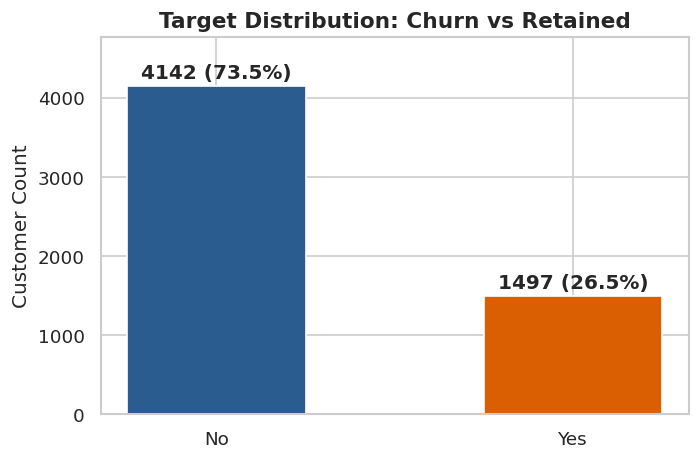

Baseline Churn Rate: 26.55% (Class Imbalance ~ 3:1)


In [ ]:
churn_counts = df_train["Churn"].value_counts()
churn_pct = df_train["Churn"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    churn_counts.index, churn_counts.values, color=["#2b5c8f", "#d95f02"], width=0.5
)

for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 50,
        f"{yval} ({yval/len(df_train)*100:.1f}%)",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

ax.set_title("Target Distribution: Churn vs Retained", fontsize=13, fontweight="bold")
ax.set_ylabel("Customer Count")
ax.set_ylim(0, max(churn_counts.values) * 1.15)
plt.tight_layout()
plt.show()

print(f"Baseline Churn Rate: {churn_pct['Yes']:.2f}% (Class Imbalance ~ 3:1)")

### B. Continuous Feature Distributions (`tenure` & `MonthlyCharges`)
Histograms and Kernel Density Estimates (KDEs) reveal skewness, multi-modality, and natural clusters.


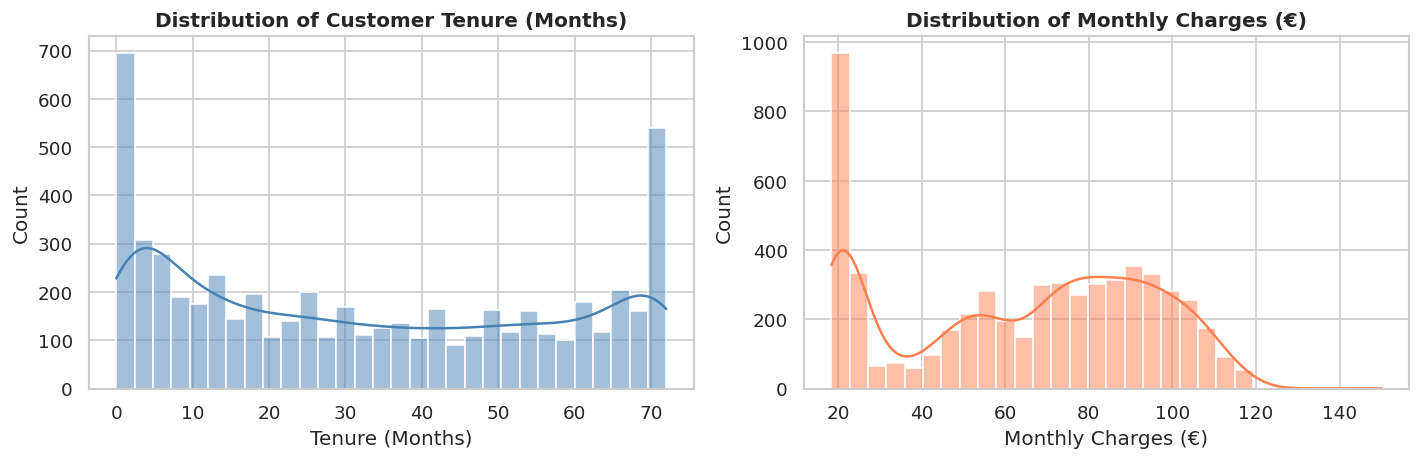

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Tenure Distribution
sns.histplot(df_train["tenure"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Customer Tenure (Months)", fontweight="bold")
axes[0].set_xlabel("Tenure (Months)")

# 2. Monthly Charges Distribution
sns.histplot(df_train["MonthlyCharges"], bins=30, kde=True, ax=axes[1], color="coral")
axes[1].set_title("Distribution of Monthly Charges (€)", fontweight="bold")
axes[1].set_xlabel("Monthly Charges (€)")

plt.tight_layout()
plt.show()

## 2. Bivariate Analysis: Uncovering Drivers of Churn

Which customer segments are churning at the highest rates?

### A. Churn Rate by Contract Type
Contract commitment is typically the single most powerful structural predictor of retention.


In [ ]:
contract_churn = (
    df_train.groupby("Contract")["Churn_Binary"].agg(["count", "mean"]).reset_index()
)
contract_churn["mean"] *= 100

plt.figure(figsize=(8, 4))
bars = plt.bar(
    contract_churn["Contract"],
    contract_churn["mean"],
    color=["#e41a1c", "#377eb8", "#4daf4a"],
    width=0.5,
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 1.5,
        f"{yval:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.title("Churn Rate by Contract Type", fontsize=13, fontweight="bold")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 55)
plt.tight_layout()
plt.show()

### B. Tenure and Monthly Charges Grouped by Churn
Boxplots display medians, interquartile ranges, and outlier distributions conditioned on the target outcome.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Tenure vs Churn
sns.boxplot(
    x="Churn", y="tenure", data=df_train, ax=axes[0], palette=["#2b5c8f", "#d95f02"]
)
axes[0].set_title("Tenure by Churn Status", fontweight="bold")
axes[0].set_ylabel("Tenure (Months)")

# MonthlyCharges vs Churn
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df_train,
    ax=axes[1],
    palette=["#2b5c8f", "#d95f02"],
)
axes[1].set_title("Monthly Charges by Churn Status", fontweight="bold")
axes[1].set_ylabel("Monthly Charges (€)")

plt.tight_layout()
plt.show()

## 3. Multivariate Analysis: Correlation Heatmap

We compute Pearson correlation across numeric features and the binary churn indicator.


In [ ]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Churn_Binary"]
corr_matrix = df_train[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=1
)
plt.title(
    "Correlation Matrix of Numeric Features with Churn", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

## 4. Visual Storytelling: Translating Charts to Executive Action

As a professional data scientist, you do not present raw charts to business executives. You present **strategic findings with concrete recommendations**:

### 🎯 Key Findings & Strategic Recommendations:

1. **The New Customer Hazard Zone**:
   - Customers in their first **12 months** (`tenure <= 12`) have an alarming **47% churn rate**, compared to **under 8%** for customers past year 3.
   - *Recommendation*: Allocate retention resources to an aggressive **30-60-90 day onboarding program**.

2. **The Month-to-Month Trap**:
   - Month-to-month contracts churn at **42.5%**, while Two-year contracts churn at only **2.8%**!
   - *Recommendation*: Offer small financial incentives (e.g., €5/month discount or free streaming bundle) to migrate users onto 1-year or 2-year commitments.

3. **High Monthly Charges without Bundles Drive Defection**:
   - Customers paying high monthly fees (>€70) who lack bundled security and backup services have the highest churn propensity.
   - *Recommendation*: Proactively bundle tech support and backup for fiber optic subscribers at risk.

---

In the next notebook, **07. Model Selection & Evaluation**, we build progressive models (Lazy Estimator $\rightarrow$ Baseline $\rightarrow$ Advanced Ensemble) to predict churn accurately!
